# Baseline vs eBPF Detection Experiment

Compares Zeek-only (baseline) against Zeek+eBPF using HistGradientBoosting across five evaluation splits. Models are selected on Split 2 and evaluated on the Split 4 Friday holdout. Seed: **104**.

**RQ1:** Does eBPF monitoring improve detection accuracy over traditional packet capture?  
**RQ5:** Does eBPF reduce false positive rates?

In [1]:
import os, sys, json, time, warnings, subprocess
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score, accuracy_score,
    average_precision_score, confusion_matrix, RocCurveDisplay,
)
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT, f'Cannot find repo root from {HERE}'
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *

FEATURE_SETS = [
    ('baseline', MODEL_SELECTION_SPLITS_BASELINE, GENERALIZATION_SPLITS_BASELINE),
    ('ebpf',     MODEL_SELECTION_SPLITS_EBPF,     GENERALIZATION_SPLITS_EBPF),
]

SUPPORTING_SPLITS = {
    'split1_group_strat': {
        'role': 'leakage_diagnostic',
        'baseline_dir': SPLITS_1_BASELINE,
        'ebpf_dir': SPLITS_1_EBPF,
        'test_file': 'test.parquet',
    },
    'split2_balanced_quota': {
        'role': 'model_selection',
        'baseline_dir': SPLITS_2_BASELINE,
        'ebpf_dir': SPLITS_2_EBPF,
        'test_file': 'test.parquet',
    },
    'split3_train_resampled': {
        'role': 'resampled_training',
        'baseline_dir': SPLITS_3_BASELINE,
        'ebpf_dir': SPLITS_3_EBPF,
        'test_file': 'test.parquet',
    },
    'split4_balanced': {
        'role': 'balanced_fairness',
        'baseline_dir': SPLITS_4_BASELINE,
        'ebpf_dir': SPLITS_4_EBPF,
        'test_file': 'test_balanced.parquet',
    },
    'split4_realistic': {
        'role': 'headline_generalization',
        'baseline_dir': SPLITS_4_BASELINE,
        'ebpf_dir': SPLITS_4_EBPF,
        'test_file': 'test_realistic.parquet',
    },
}

print('[*] Repo root:', REPO_ROOT)
print('[*] Split 2 model-selection baseline:', MODEL_SELECTION_SPLITS_BASELINE)
print('[*] Split 2 model-selection ebpf    :', MODEL_SELECTION_SPLITS_EBPF)
print('[*] Split 4 headline baseline       :', GENERALIZATION_SPLITS_BASELINE)
print('[*] Split 4 headline ebpf           :', GENERALIZATION_SPLITS_EBPF)
print('[*] Supporting split keys           :', ', '.join(SUPPORTING_SPLITS.keys()))


BASELINE_COLOR = "#4C78A8"
EBPF_COLOR = "#F58518"
NEUTRAL_COLOR = "#9AA1A9"

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#6B7280',
    'axes.labelcolor': '#111827',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#374151',
    'ytick.color': '#374151',
    'grid.color': '#D7DBDF',
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'legend.frameon': False,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

def savefig(fig, path, dpi=180):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')

def bootstrap_ci(samples, alpha=0.05):
    arr = np.asarray(samples, dtype=float)
    if arr.size == 0:
        return float('nan'), float('nan')
    return float(np.quantile(arr, alpha / 2.0)), float(np.quantile(arr, 1.0 - alpha / 2.0))


[*] Repo root: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel
[*] Split 2 model-selection baseline: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split2_balanced_quota_baseline_seed104
[*] Split 2 model-selection ebpf    : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split2_balanced_quota_ebpf_seed104
[*] Split 4 headline baseline       : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_baseline_seed104
[*] Split 4 headline ebpf           : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_ebpf_seed104
[*] Supporting split keys           : split1_group_strat, split2_balanced_quota, split3_train_resampled, split4_balanced, split4_realistic


## Helper functions

In [2]:
DROP_COLS = [
    'label_family', 'is_attack', 'day', 'label_raw', 'run_id',
    'ts', 'start_ts', 'end_ts', 't_end', 'orig_h', 'resp_h', 'src_ip', 'dst_ip', 'k',
    'label_time_offset_sec', 'label_halfday_shift_sec',
    'label_window_pre_slop_sec', 'label_window_post_slop_sec',
]

In [3]:
def _numeric_cols(df: pd.DataFrame):
    X = df.drop(columns=DROP_COLS, errors='ignore')
    return [
        c for c in X.columns
        if pd.api.types.is_numeric_dtype(X[c]) and not X[c].isna().all()
    ]

In [4]:
def make_imputer_on_train(train_df: pd.DataFrame, feat: list):
    from sklearn.impute import SimpleImputer
    X_raw = train_df.drop(columns=DROP_COLS, errors='ignore')[feat]
    imp = SimpleImputer(strategy='median')
    imp.fit(X_raw)
    return imp

In [5]:
def prepare_with_imputer(df: pd.DataFrame, feat: list, imputer):
    X_raw = df.drop(columns=DROP_COLS, errors='ignore').copy()
    for c in feat:
        if c not in X_raw.columns:
            X_raw[c] = 0.0
    X_raw = X_raw[feat]
    X_arr = imputer.transform(X_raw)
    X_out = pd.DataFrame(X_arr, columns=feat, index=df.index)
    y = (df['is_attack'] == 1).astype(int).to_numpy()
    labels = df['label_family'].astype(str)
    return X_out, y, labels

In [6]:
def load_split(splits_dir: Path, test_file: str = 'test.parquet'):
    tr = pd.read_parquet(splits_dir / 'train.parquet')
    va = pd.read_parquet(splits_dir / 'val.parquet')
    te = pd.read_parquet(splits_dir / test_file)
    return tr, va, te

In [7]:
def binary_metrics(y_true, y_pred, y_prob=None) -> dict:
    m = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }
    if y_prob is not None:
        try:
            m['roc_auc'] = float(roc_auc_score(y_true, y_prob))
            m['pr_auc'] = float(average_precision_score(y_true, y_prob))
        except Exception:
            m['roc_auc'] = None
            m['pr_auc'] = None
    return m

In [8]:
def tune_threshold(y_val, y_prob_val):
    from sklearn.metrics import roc_curve
    n_pos = int((y_val == 1).sum())
    if n_pos < 10:
        print(f'    [!] Only {n_pos} validation positives; using threshold=0.5')
        return 0.5
    _, _, thresholds = roc_curve(y_val, y_prob_val)
    f1s = [
        f1_score(y_val, (y_prob_val >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best = float(thresholds[int(np.argmax(f1s))])
    print(f'    Val-tuned threshold: {best:.5f}  (best val F1={max(f1s):.4f})')
    return best

In [9]:
def print_overfit_table(name: str, tr: dict, va: dict, te: dict):
    print(f'\n[*] {name}')
    fmt = '    {split:6s}  acc={accuracy:.4f}  prec={precision:.4f}  rec={recall:.4f}  f1={f1:.4f}  roc_auc={auc}  pr_auc={pr}'
    for split, m in [('train', tr), ('val', va), ('test', te)]:
        print(fmt.format(
            split=split,
            auc=f'{m["roc_auc"]:.4f}' if m.get('roc_auc') is not None else 'N/A',
            pr=f'{m["pr_auc"]:.4f}' if m.get('pr_auc') is not None else 'N/A',
            **{k: v for k, v in m.items() if k not in ('roc_auc', 'pr_auc')},
        ))

In [10]:
def plot_confusion(y_true, y_pred, title: str, out_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm_n, cmap='Blues')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f'{cm[i, j]}\n({cm_n[i, j]:.1%})',
                ha='center', va='center',
                color='white' if cm_n[i, j] > 0.5 else 'black',
                fontsize=9,
            )
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['BENIGN', 'ATTACK'])
    ax.set_yticklabels(['BENIGN', 'ATTACK'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

In [11]:
def fit_hgb_pack(split_dir: Path):
    tr_df = pd.read_parquet(split_dir / 'train.parquet')
    va_df = pd.read_parquet(split_dir / 'val.parquet')
    feat = _numeric_cols(tr_df)
    imp = make_imputer_on_train(tr_df, feat)
    Xtr, ytr, ltr = prepare_with_imputer(tr_df, feat, imp)
    Xva, yva, lva = prepare_with_imputer(va_df, feat, imp)

    clf = HistGradientBoostingClassifier(**HGB_PARAMS)
    t0 = time.time()
    clf.fit(Xtr, ytr)
    fit_seconds = time.time() - t0

    tr_prob = clf.predict_proba(Xtr)[:, 1]
    va_prob = clf.predict_proba(Xva)[:, 1]
    best_thr = tune_threshold(yva, va_prob)

    train_metrics = binary_metrics(ytr, (tr_prob >= best_thr).astype(int), tr_prob)
    val_metrics = binary_metrics(yva, (va_prob >= best_thr).astype(int), va_prob)

    return {
        'model': clf,
        'imputer': imp,
        'features': feat,
        'threshold': best_thr,
        'fit_seconds': fit_seconds,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
    }

In [12]:
def evaluate_hgb_pack(pack: dict, split_dir: Path, test_file: str):
    test_df = pd.read_parquet(split_dir / test_file)
    Xte, yte, lte = prepare_with_imputer(test_df, pack['features'], pack['imputer'])
    te_prob = pack['model'].predict_proba(Xte)[:, 1]
    te_pred = (te_prob >= pack['threshold']).astype(int)
    test_metrics = binary_metrics(yte, te_pred, te_prob)
    return {
        'test_metrics': test_metrics,
        'y_test': yte,
        'y_prob': te_prob,
        'y_pred': te_pred,
        'labels_test': lte,
        'n_rows': len(yte),
        'n_attacks': int(yte.sum()),
    }

In [13]:
def run_hgb_split(fs_name: str, split_name: str, split_dir: Path, test_file: str, *, save_prefix: str | None = None):
    print(f'\n[*] HGB {fs_name} on {split_name} ({test_file})')
    pack = fit_hgb_pack(split_dir)
    ev = evaluate_hgb_pack(pack, split_dir, test_file)
    print_overfit_table(
        f'HGB {fs_name} [{split_name}]',
        pack['train_metrics'], pack['val_metrics'], ev['test_metrics']
    )

    out = {
        'model_path': None,
        'features': pack['features'],
        'threshold': pack['threshold'],
        'fit_seconds': pack['fit_seconds'],
        'train': pack['train_metrics'],
        'val': pack['val_metrics'],
        'test': ev['test_metrics'],
        'y_test': ev['y_test'].tolist(),
        'y_prob': ev['y_prob'].tolist(),
        'y_pred': ev['y_pred'].tolist(),
        'n_rows': ev['n_rows'],
        'n_attacks': ev['n_attacks'],
        'split_name': split_name,
        'test_file': test_file,
    }

    if save_prefix is not None:
        model_path = MODELS_DIR / f'{save_prefix}.joblib'
        joblib.dump(
            {
                'model': pack['model'],
                'imputer': pack['imputer'],
                'features': pack['features'],
                'threshold': pack['threshold'],
                'selected_model_name': 'hgb_balanced',
                'seed': RANDOM_SEED,
                'split_name': split_name,
                'test_file': test_file,
            },
            model_path,
        )
        plot_confusion(
            ev['y_test'], ev['y_pred'],
            f'HGB {fs_name}: {split_name} ({test_file})',
            REPORTS_DIR / f'{save_prefix}_confusion.png',
        )
        out['model_path'] = str(model_path)
    return out

In [14]:
def bootstrap_auc(y_true, y_prob, n=200, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, yp))
    return np.array(aucs)

## Experiment A: Split 2 Model Selection

Trains all model families on the balanced-quota split to pick the best family. Metrics here are inflated by session overlap, so this is for selection only and not for headline claims.

In [15]:
from ml.notebooks.modeling_pipeline import (
    rank_models,
    load_split as mp_load_split,
    prepare_split as mp_prepare_split,
    align_to_features as mp_align_to_features,
    binary_metrics as mp_binary_metrics,
)

model_selection_rows = []
selected_split2 = {}

for fs_name, split2_dir, _split4_dir in FEATURE_SETS:
    print(f'\nSplit 2 model selection: {fs_name}')
    tr_df, va_df, te_df = mp_load_split(Path(split2_dir), test_file='test.parquet')
    tr = mp_prepare_split(tr_df)
    va = mp_prepare_split(va_df, feature_list=tr.features)
    te = mp_prepare_split(te_df, feature_list=tr.features)

    Xtr = mp_align_to_features(tr.X, tr.features)
    Xva = mp_align_to_features(va.X, tr.features)
    Xte = mp_align_to_features(te.X, tr.features)

    best_name, best_res, board = rank_models(Xtr, tr.y, Xva, va.y, seed=RANDOM_SEED)
    print(board.to_string(index=False, float_format='{:.4f}'.format))

    if hasattr(best_res['model'], 'predict_proba'):
        te_prob = best_res['model'].predict_proba(Xte)[:, 1]
    else:
        te_raw = best_res['model'].decision_function(Xte)
        te_prob = (te_raw - np.min(te_raw)) / (np.max(te_raw) - np.min(te_raw) + 1e-12)
    te_pred = (te_prob >= best_res['tuned_threshold']).astype(int)
    te_metrics = mp_binary_metrics(te.y, te_pred, te_prob)

    board_export = board.copy()
    board_export.insert(0, 'feature_set', fs_name)
    board_export.insert(0, 'split', 'split2_balanced_quota')
    board_export['selected'] = board_export['model'].eq(best_name)
    model_selection_rows.append(board_export)

    selected_pack = {
        'model': best_res['model'],
        'features': tr.features,
        'threshold': float(best_res['tuned_threshold']),
        'selected_model_name': best_name,
        'selection_score': float(best_res['selection_score']),
        'overfit_gap_auc': float(best_res['overfit_gap_auc']),
        'overfit_gap_f1': float(best_res['overfit_gap_f1']),
        'train_metrics': best_res['train'],
        'val_metrics': best_res['val'],
        'test_metrics': te_metrics,
        'selected_on_split': 'split2_balanced_quota',
        'selection_protocol': 'validation_roc_auc_minus_overfit_penalty',
        'seed': RANDOM_SEED,
    }
    selected_split2[fs_name] = selected_pack

    out_path = MODELS_DIR / f'{fs_name}_selected_model_split2_seed{RANDOM_SEED}.joblib'
    legacy_path = MODELS_DIR / f'{fs_name}_best_model_seed{RANDOM_SEED}.joblib'
    joblib.dump(selected_pack, out_path)
    joblib.dump(selected_pack, legacy_path)
    print(f"[*] Selected model family for {fs_name}: {best_name}")
    print(f"    test metrics: f1={te_metrics['f1']:.4f}  roc_auc={te_metrics['roc_auc']:.4f}  pr_auc={te_metrics['pr_auc']:.4f}")
    print(f"[+] Saved Split 2 selection artifact: {out_path}")

model_selection_df = pd.concat(model_selection_rows, ignore_index=True)
print('\nSplit 2 candidate ranking summary')
print(model_selection_df.to_string(index=False, float_format='{:.4f}'.format))

model_selection_csv = REPORTS_DIR / f'model_selection_split2_seed{RANDOM_SEED}.csv'
model_selection_df.to_csv(model_selection_csv, index=False)
print(f'\n[+] Saved model-selection summary: {model_selection_csv}')



Split 2 model selection: baseline


          model  val_auc  val_f1  train_auc  train_f1  overfit_gap_auc  overfit_gap_f1  selection_score
   hgb_balanced   0.9984  0.9861     0.9993    0.9882           0.0010          0.0022           0.9973
    rf_balanced   0.9984  0.9851     0.9999    0.9896           0.0015          0.0044           0.9965
    et_balanced   0.9962  0.9811     0.9989    0.9849           0.0027          0.0037           0.9940
logreg_balanced   0.8639  0.8844     0.8635    0.8818           0.0000          0.0000           0.8639
[*] Selected model family for baseline: hgb_balanced
    test metrics: f1=0.9822  roc_auc=0.9972  pr_auc=0.9967
[+] Saved Split 2 selection artifact: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/baseline_selected_model_split2_seed104.joblib

Split 2 model selection: ebpf
          model  val_auc  val_f1  train_auc  train_f1  overfit_gap_auc  overfit_gap_f1  selection_score
   hgb_balanced   0.9993  0.9932     0.9998    0.9942           0.0005          0.0

## Model Family Selection Landscape

`hgb_balanced` leads on both AUC and F1 with the smallest overfit gap. It is selected for all downstream experiments.

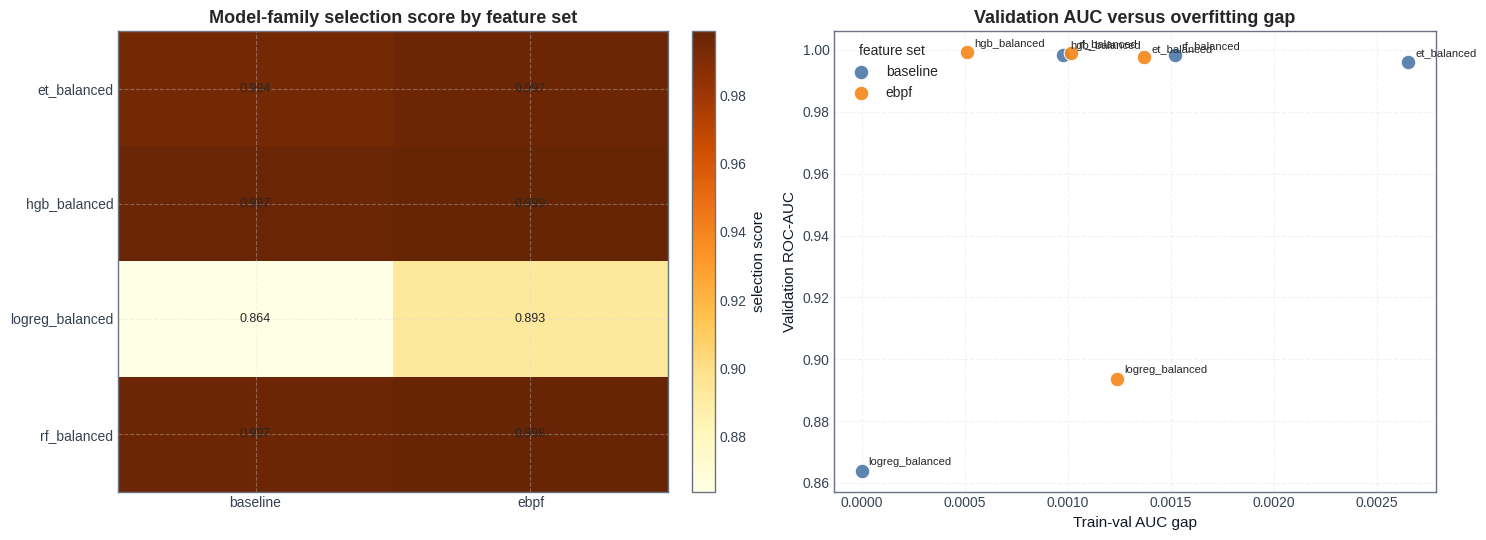

[+] Saved model-selection landscape: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/model_selection_landscape_seed104.png


In [16]:
if not model_selection_df.empty:
    rank_plot = model_selection_df.copy()
    rank_plot['feature_set'] = pd.Categorical(rank_plot['feature_set'], ['baseline', 'ebpf'], ordered=True)
    rank_plot = rank_plot.sort_values(['feature_set', 'selection_score'], ascending=[True, False]).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    score_pivot = rank_plot.pivot(index='model', columns='feature_set', values='selection_score')
    im = axes[0].imshow(score_pivot.fillna(np.nan).to_numpy(), cmap='YlOrBr', aspect='auto')
    axes[0].set_title('Model-family selection score by feature set')
    axes[0].set_xticks(range(len(score_pivot.columns)))
    axes[0].set_xticklabels(score_pivot.columns)
    axes[0].set_yticks(range(len(score_pivot.index)))
    axes[0].set_yticklabels(score_pivot.index)
    for i, model_name in enumerate(score_pivot.index):
        for j, fs_name in enumerate(score_pivot.columns):
            val = score_pivot.loc[model_name, fs_name]
            if pd.notna(val):
                axes[0].text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label='selection score')

    for fs_name, color in [('baseline', BASELINE_COLOR), ('ebpf', EBPF_COLOR)]:
        subset = rank_plot[rank_plot['feature_set'] == fs_name]
        axes[1].scatter(
            subset['overfit_gap_auc'], subset['val_auc'],
            s=110, color=color, alpha=0.9, label=fs_name,
            edgecolor='white', linewidth=0.8,
        )
        for _, row in subset.iterrows():
            axes[1].annotate(row['model'], (row['overfit_gap_auc'], row['val_auc']), xytext=(5, 4), textcoords='offset points', fontsize=8)
    axes[1].set_title('Validation AUC versus overfitting gap')
    axes[1].set_xlabel('Train-val AUC gap')
    axes[1].set_ylabel('Validation ROC-AUC')
    axes[1].legend(title='feature set')

    plt.tight_layout()
    out = REPORTS_DIR / f'model_selection_landscape_seed{RANDOM_SEED}.png'
    savefig(fig, out)
    plt.show()
    print(f'[+] Saved model-selection landscape: {out}')


## Experiment B: Main Evaluation on Split 4

Refits `hgb_balanced` on Split 4 (Mon-Thu train, Friday test). The threshold is set via a matched-recall protocol so both models operate at the same recall point for a fair FPR comparison.

In [17]:
from ml.notebooks.modeling_pipeline import (
    fit_model_family_on_split,
    evaluate_saved_pack,
    bootstrap_metric_ci,
    load_model_pack,
    select_threshold,
    metrics_at_threshold,
)

split4_fitted = {}
for fs_name, _split2_dir, split4_dir in FEATURE_SETS:
    selection_pack = load_model_pack(fs_name, artifact='selection', seed=RANDOM_SEED)
    model_name = selection_pack['selected_model_name']
    feature_list = selection_pack['features']
    print(f'\nSplit 4 fit for headline analysis: {fs_name} ({model_name})')
    split4_fitted[fs_name] = fit_model_family_on_split(
        Path(split4_dir),
        feature_list=feature_list,
        model_name=model_name,
        test_file='test_realistic.parquet',
        seed=RANDOM_SEED,
        threshold_mode='f1',
    )

matched_recall_target = min(
    split4_fitted[fs_name]['val_metrics']['recall']
    for fs_name in split4_fitted
)
print(f"\n[*] Shared validation recall target for RQ5: {matched_recall_target:.4f}")
print("    Defined as the lower of the two validation recalls at each model's own F1-optimal threshold.")

headline_results = {}
split4_balanced_results = {}
rq5_rows = []

for fs_name, _split2_dir, split4_dir in FEATURE_SETS:
    selection_pack = load_model_pack(fs_name, artifact='selection', seed=RANDOM_SEED)
    model_name = selection_pack['selected_model_name']
    fitted = split4_fitted[fs_name]

    matched_thr = select_threshold(
        fitted['y_val'],
        fitted['y_val_score'],
        threshold_mode='recall',
        target_recall=matched_recall_target,
    )
    val_matched = metrics_at_threshold(fitted['y_val'], fitted['y_val_score'], matched_thr)
    test_matched = metrics_at_threshold(fitted['y_test'], fitted['y_score'], matched_thr)
    test_pred_matched = (fitted['y_score'] >= matched_thr).astype(int)

    balanced_df = pd.read_parquet(Path(split4_dir) / 'test_balanced.parquet')
    balanced = evaluate_saved_pack(
        {
            'model': fitted['model'],
            'features': fitted['features'],
            'threshold': matched_thr,
        },
        balanced_df,
    )

    roc_ci = bootstrap_metric_ci(
        fitted['y_test'], fitted['y_score'],
        metric='roc_auc', n_boot=300, seed=RANDOM_SEED,
    )
    pr_ci = bootstrap_metric_ci(
        fitted['y_test'], fitted['y_score'],
        metric='pr_auc', n_boot=300, seed=RANDOM_SEED,
    )

    print(f'\n[*] {fs_name} / {model_name}')
    print(f"    F1 reference threshold on validation      : {fitted['threshold']:.6f}")
    print(f"    Matched-recall threshold on validation   : {matched_thr:.6f}")
    print("    Validation metrics at F1 threshold")
    print(pd.DataFrame([fitted['val_metrics']]).to_string(index=False, float_format='{:.4f}'.format))
    print("    Validation metrics at matched-recall threshold")
    print(pd.DataFrame([val_matched]).to_string(index=False, float_format='{:.4f}'.format))
    print("    Realistic-test metrics at matched-recall threshold")
    print(pd.DataFrame([test_matched]).to_string(index=False, float_format='{:.4f}'.format))
    print(f"    Headline ROC-AUC 95% CI: [{roc_ci['low']:.4f}, {roc_ci['high']:.4f}]")
    print(f"    Headline PR-AUC  95% CI: [{pr_ci['low']:.4f}, {pr_ci['high']:.4f}]")

    headline_path = MODELS_DIR / f'{fs_name}_headline_model_seed{RANDOM_SEED}.joblib'
    headline_pack = {
        'model': fitted['model'],
        'features': fitted['features'],
        'threshold': float(matched_thr),
        'selected_model_name': model_name,
        'selected_on_split': 'split2_balanced_quota',
        'trained_on_split': 'split4_dual_eval',
        'headline_test_file': 'test_realistic.parquet',
        'threshold_mode': 'matched_recall',
        'target_recall': float(matched_recall_target),
        'f1_reference_threshold': float(fitted['threshold']),
        'f1_reference_val_metrics': fitted['val_metrics'],
        'f1_reference_test_metrics': fitted['test_metrics'],
        'seed': RANDOM_SEED,
    }
    joblib.dump(headline_pack, headline_path)

    plot_confusion(
        fitted['y_test'], test_pred_matched,
        f'{model_name} {fs_name}: Split 4 realistic (matched recall)',
        REPORTS_DIR / f'{fs_name}_headline_split4_realistic_seed{RANDOM_SEED}_confusion.png',
    )
    plot_confusion(
        balanced['y'], balanced['pred'],
        f'{model_name} {fs_name}: Split 4 balanced (matched recall)',
        REPORTS_DIR / f'{fs_name}_headline_split4_balanced_seed{RANDOM_SEED}_confusion.png',
    )

    headline_results[fs_name] = {
        'model_path': str(headline_path),
        'model_name': model_name,
        'features': fitted['features'],
        'threshold': float(matched_thr),
        'threshold_mode': 'matched_recall',
        'target_recall': float(matched_recall_target),
        'f1_reference_threshold': float(fitted['threshold']),
        'train': fitted['train_metrics'],
        'val': val_matched,
        'test': test_matched,
        'f1_reference_val': fitted['val_metrics'],
        'f1_reference_test': fitted['test_metrics'],
        'roc_auc_ci': roc_ci,
        'pr_auc_ci': pr_ci,
        'y_test': fitted['y_test'].tolist(),
        'y_prob': fitted['y_score'].tolist(),
        'y_pred': test_pred_matched.tolist(),
        'test_file': 'test_realistic.parquet',
        'split_name': 'split4_realistic',
        'n_rows': fitted['n_rows'],
        'n_attacks': fitted['n_attacks'],
    }
    split4_balanced_results[fs_name] = {
        'model_name': model_name,
        'test': balanced['metrics'],
        'y_test': balanced['y'].tolist(),
        'y_prob': balanced['score'].tolist(),
        'y_pred': balanced['pred'].tolist(),
        'test_file': 'test_balanced.parquet',
        'split_name': 'split4_balanced',
        'n_rows': int(len(balanced['y'])),
        'n_attacks': int(np.sum(balanced['y'])),
    }
    rq5_rows.append({
        'feature_set': fs_name,
        'model': model_name,
        'threshold_mode': 'matched_recall',
        'target_val_recall': matched_recall_target,
        'validation_threshold': matched_thr,
        'val_precision': val_matched['precision'],
        'val_recall': val_matched['recall'],
        'val_fpr': val_matched['fpr'],
        'test_precision': test_matched['precision'],
        'test_recall': test_matched['recall'],
        'test_fpr': test_matched['fpr'],
        'test_fp': test_matched['fp'],
        'test_tp': test_matched['tp'],
        'test_fn': test_matched['fn'],
        'test_tn': test_matched['tn'],
    })

headline_rows = []
for fs_name in ['baseline', 'ebpf']:
    r = headline_results[fs_name]
    te = r['test']
    headline_rows.append({
        'headline_split': 'split4_realistic',
        'model': r['model_name'],
        'feature_set': fs_name,
        'rows': r['n_rows'],
        'attacks': r['n_attacks'],
        'threshold_mode': r['threshold_mode'],
        'target_val_recall': r['target_recall'],
        'threshold': r['threshold'],
        'f1_reference_threshold': r['f1_reference_threshold'],
        'accuracy': te.get('accuracy'),
        'precision': te.get('precision'),
        'recall': te.get('recall'),
        'f1': te.get('f1'),
        'fpr': te.get('fpr'),
        'roc_auc': te.get('roc_auc'),
        'roc_auc_ci_low': r['roc_auc_ci']['low'],
        'roc_auc_ci_high': r['roc_auc_ci']['high'],
        'pr_auc': te.get('pr_auc'),
        'pr_auc_ci_low': r['pr_auc_ci']['low'],
        'pr_auc_ci_high': r['pr_auc_ci']['high'],
    })

headline_df = pd.DataFrame(headline_rows)
print('\nHeadline result: Split 4 realistic (matched recall operating point)')
print(headline_df.to_string(index=False, float_format='{:.4f}'.format))

headline_csv = REPORTS_DIR / f'headline_split4_realistic_seed{RANDOM_SEED}.csv'
headline_df.to_csv(headline_csv, index=False)
print(f'\n[+] Saved headline summary: {headline_csv}')

rq5_df = pd.DataFrame(rq5_rows).sort_values('feature_set').reset_index(drop=True)
print('\nRQ5 operating-point comparison: matched validation recall')
print(rq5_df.to_string(index=False, float_format='{:.4f}'.format))
rq5_csv = REPORTS_DIR / f'rq5_false_positive_control_split4_realistic_seed{RANDOM_SEED}.csv'
rq5_df.to_csv(rq5_csv, index=False)
print(f'\n[+] Saved RQ5 comparison table: {rq5_csv}')

base_rq5 = rq5_df.loc[rq5_df['feature_set'] == 'baseline'].iloc[0]
ebpf_rq5 = rq5_df.loc[rq5_df['feature_set'] == 'ebpf'].iloc[0]
print('\nRQ5 deltas (eBPF - baseline) on Split 4 realistic at matched validation recall')
print(f"    precision delta: {ebpf_rq5['test_precision'] - base_rq5['test_precision']:+.4f}")
print(f"    recall delta   : {ebpf_rq5['test_recall'] - base_rq5['test_recall']:+.4f}")
print(f"    FPR delta      : {ebpf_rq5['test_fpr'] - base_rq5['test_fpr']:+.4f}")
print(f"    false positives: {int(ebpf_rq5['test_fp']) - int(base_rq5['test_fp']):+d}")

# Memory cleanup: free fitted objects after headline_results is populated
import gc as _gc
del split4_fitted
_gc.collect()
print('[*] Freed split4_fitted from memory.')


Split 4 fit for headline analysis: baseline (hgb_balanced)

Split 4 fit for headline analysis: ebpf (hgb_balanced)

[*] Shared validation recall target for RQ5: 0.8713
    Defined as the lower of the two validation recalls at each model's own F1-optimal threshold.

[*] baseline / hgb_balanced
    F1 reference threshold on validation      : 0.000530
    Matched-recall threshold on validation   : 0.000544
    Validation metrics at F1 threshold
 accuracy  precision  recall     f1    fpr     tn    fp  fn   tp  roc_auc  pr_auc
   0.9661     0.1191  0.8815 0.2099 0.0335 349064 12103 220 1637   0.9722  0.0913
    Validation metrics at matched-recall threshold
 accuracy  precision  recall     f1    fpr     tn    fp  fn   tp  roc_auc  pr_auc  threshold
   0.9664     0.1191  0.8713 0.2095 0.0331 349195 11972 239 1618   0.9722  0.0913     0.0005
    Realistic-test metrics at matched-recall threshold
 accuracy  precision  recall     f1    fpr     tn    fp     fn    tp  roc_auc  pr_auc  threshold


## Multi-Seed Robustness Check

Reruns the main experiment across seeds 0, 1, 2, 3, and 104. The direction is consistent (baseline > eBPF in all 5 seeds), but seed 104 produced the largest eBPF gap to date (0.205 vs a mean of 0.078 for the other seeds), which drives higher variance on the eBPF side.

[*] Loaded cached multi-seed results from /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/multi_seed_headline_seed104.csv

[*] Per-seed results:
                 gap         test_auc        
feature_set baseline    ebpf baseline    ebpf
seed                                         
0             0.0692  0.1192   0.9307  0.8808
1             0.0731  0.1509   0.9268  0.8491
2             0.0934  0.1258   0.9065  0.8742
3             0.0776  0.1600   0.9223  0.8400
104           0.0751  0.2046   0.9249  0.7954

[*] Aggregate across seeds (mean +/- std):
feature_set  mean_test_auc  std_test_auc  mean_gap  std_gap  n_seeds
   baseline         0.9223        0.0093    0.0777   0.0093        5
       ebpf         0.8479        0.0339    0.1521   0.0339        5

[*] Baseline > eBPF in 5/5 seeds (direction consistent: True)


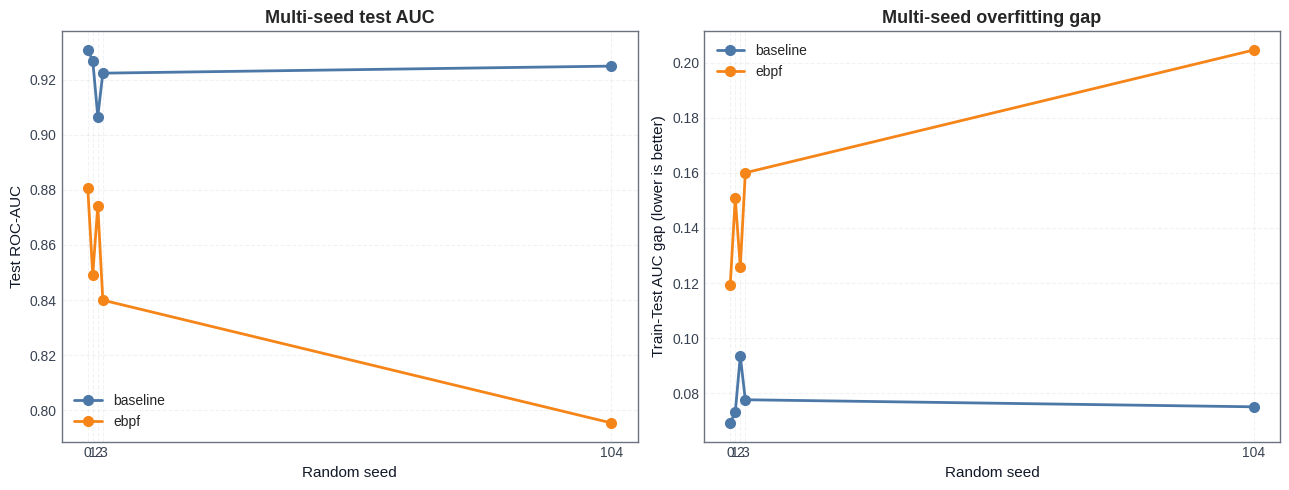

[+] Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/multi_seed_headline_104.png


In [18]:
import gc
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np
from pathlib import Path

MULTI_SEEDS = [RANDOM_SEED, 0, 1, 2, 3]
MULTI_SEED_CACHE = REPORTS_DIR / f'multi_seed_headline_seed{RANDOM_SEED}.csv'

if MULTI_SEED_CACHE.exists():
    ms_df = pd.read_csv(MULTI_SEED_CACHE)
    print(f'[*] Loaded cached multi-seed results from {MULTI_SEED_CACHE}')
else:
    sel_baseline = load_model_pack('baseline', artifact='selection', seed=RANDOM_SEED)
    sel_ebpf     = load_model_pack('ebpf',     artifact='selection', seed=RANDOM_SEED)
    feat_map = {'baseline': sel_baseline['features'], 'ebpf': sel_ebpf['features']}
    dir_map  = {'baseline': SPLITS_4_BASELINE, 'ebpf': SPLITS_4_EBPF}

    # Load each feature set's arrays ONCE, outside the seed loop
    # float32 halves RAM vs float64; reading only needed columns avoids
    # loading 30+ parquet columns when only 10-17 feature cols are needed.
    arrays = {}
    for fs_name in ['baseline', 'ebpf']:
        feat = feat_map[fs_name]
        d    = dir_map[fs_name]
        load_cols_tr = list(dict.fromkeys(feat + ['is_attack']))
        load_cols_te = list(dict.fromkeys(feat + ['is_attack']))

        print(f'[*] Loading {fs_name} train ({len(feat)} feature cols) ...', flush=True)
        tr = pd.read_parquet(Path(d) / 'train.parquet', columns=load_cols_tr)
        avail = [c for c in feat if c in tr.columns
                 and pd.api.types.is_numeric_dtype(tr[c])]
        X_tr = tr[avail].to_numpy(dtype='float32')
        y_tr = (tr['is_attack'] == 1).astype('int8').to_numpy()
        del tr; gc.collect()

        print(f'[*] Loading {fs_name} test_realistic ...', flush=True)
        te = pd.read_parquet(Path(d) / 'test_realistic.parquet', columns=load_cols_te)
        avail_te = [c for c in avail if c in te.columns]
        X_te = te[avail_te].to_numpy(dtype='float32')
        y_te = (te['is_attack'] == 1).astype('int8').to_numpy()
        del te; gc.collect()

        arrays[fs_name] = (X_tr, y_tr, X_te, y_te, avail)
        print(f'    X_train={X_tr.shape} ({X_tr.nbytes/1e6:.0f} MB)  '
              f'X_test={X_te.shape} ({X_te.nbytes/1e6:.0f} MB)')

    # One model at a time: fit -> score -> del -> gc
    ms_rows = []
    # Disable early_stopping for multi-seed: avoids HGB holding an internal
    # 10%-of-train validation copy (saves ~120K rows x n_features per fit).
    ms_hgb_params = {**HGB_PARAMS, 'early_stopping': False}

    for seed in MULTI_SEEDS:
        for fs_name in ['baseline', 'ebpf']:
            X_tr, y_tr, X_te, y_te, avail = arrays[fs_name]
            print(f'[*] Fitting {fs_name} seed={seed} ...', end=' ', flush=True)
            model = HistGradientBoostingClassifier(**{**ms_hgb_params, 'random_state': seed})
            model.fit(X_tr, y_tr)
            tr_prob = model.predict_proba(X_tr)[:, 1]
            te_prob = model.predict_proba(X_te)[:, 1]
            tr_auc = float(roc_auc_score(y_tr, tr_prob))
            te_auc = float(roc_auc_score(y_te, te_prob))
            te_ap  = float(average_precision_score(y_te, te_prob))
            ms_rows.append({'seed': seed, 'feature_set': fs_name,
                            'train_auc': tr_auc, 'test_auc': te_auc,
                            'test_ap': te_ap, 'gap': tr_auc - te_auc})
            print(f'test_auc={te_auc:.4f}  gap={tr_auc - te_auc:.4f}')
            del model, tr_prob, te_prob; gc.collect()

    del arrays; gc.collect()

    ms_df = pd.DataFrame(ms_rows)
    ms_df.to_csv(MULTI_SEED_CACHE, index=False)
    print(f'[+] Saved: {MULTI_SEED_CACHE}')

print()
print('[*] Per-seed results:')
pivot = ms_df.pivot_table(index='seed', columns='feature_set',
                          values=['test_auc', 'gap'], aggfunc='first')
print(pivot.round(4).to_string())

print()
print('[*] Aggregate across seeds (mean +/- std):')
agg = ms_df.groupby('feature_set').agg(
    mean_test_auc=('test_auc', 'mean'),
    std_test_auc=('test_auc', 'std'),
    mean_gap=('gap', 'mean'),
    std_gap=('gap', 'std'),
    n_seeds=('seed', 'count'),
).reset_index()
print(agg.to_string(index=False, float_format='{:.4f}'.format))

base_aucs = ms_df[ms_df['feature_set'] == 'baseline']['test_auc'].values
ebpf_aucs = ms_df[ms_df['feature_set'] == 'ebpf']['test_auc'].values
n_wins = int((base_aucs > ebpf_aucs).sum())
print(f'\n[*] Baseline > eBPF in {n_wins}/{len(MULTI_SEEDS)} seeds '
      f'(direction consistent: {n_wins == len(MULTI_SEEDS)})')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, ylabel, title in [
    (axes[0], 'test_auc', 'Test ROC-AUC', 'Multi-seed test AUC'),
    (axes[1], 'gap',      'Train-Test AUC gap (lower is better)', 'Multi-seed overfitting gap'),
]:
    for fs_name, color in [('baseline', BASELINE_COLOR), ('ebpf', EBPF_COLOR)]:
        sub = ms_df[ms_df['feature_set'] == fs_name].sort_values('seed')
        ax.plot(sub['seed'], sub[metric], marker='o', color=color,
                linewidth=2, markersize=7, label=fs_name)
    ax.set_xlabel('Random seed')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.set_xticks(MULTI_SEEDS)

plt.tight_layout()
ms_fig = REPORTS_DIR / f'multi_seed_headline_{RANDOM_SEED}.png'
fig.savefig(ms_fig, dpi=180, bbox_inches='tight')
plt.show()
print(f'[+] Saved: {ms_fig}')

### Multi-Seed Interpretation

Baseline AUC ranges from 0.907 to 0.931 (std 0.009). eBPF AUC ranges from 0.795 to 0.881 (std 0.034), with notably higher variance.

Seed 104 is an outlier on the eBPF side (AUC 0.795, gap 0.205), but the negative direction holds across all seeds.

## Experiment C: Supporting Diagnostics Across All Splits

Refits on each split and records train/val/test AUC and F1. Results feed into the gap analysis in notebook 04.

                 split                    role        model feature_set threshold_mode  target_recall   rows  attacks  test_f1  test_roc_auc  test_pr_auc  test_precision  test_recall  test_fpr
 split2_balanced_quota         model_selection hgb_balanced    baseline matched_recall         0.8713   7220     3591   0.9244        0.9972       0.9967          0.9930       0.8647    0.0061
 split2_balanced_quota         model_selection hgb_balanced        ebpf matched_recall         0.8713   7220     3591   0.9284        0.9983       0.9979          0.9974       0.8683    0.0022
      split4_realistic headline_generalization hgb_balanced    baseline matched_recall         0.8713 546207   247953   0.5104        0.9209       0.8638          0.8328       0.3680    0.0614
      split4_realistic headline_generalization hgb_balanced        ebpf matched_recall         0.8713 546207   247953   0.4989        0.8005       0.7512          0.7762       0.3675    0.0881
       split4_balanced       balanc

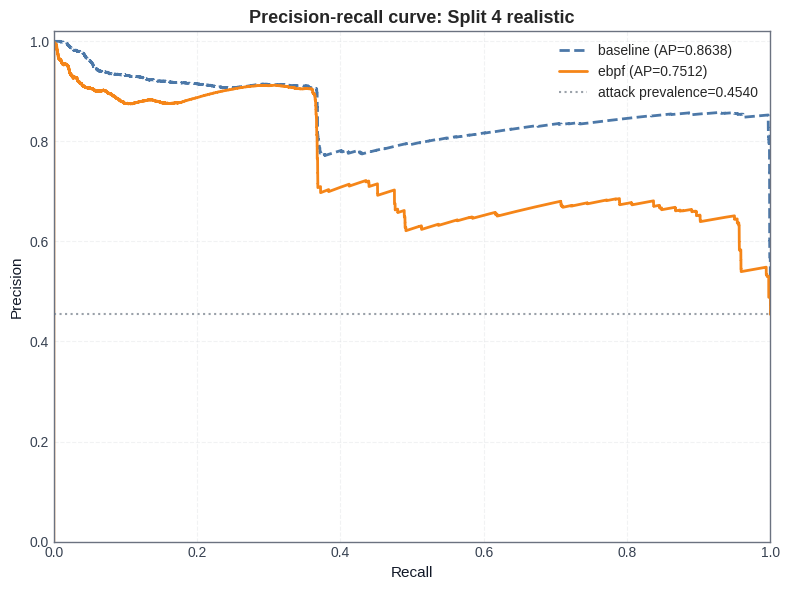

[+] Saved PR plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/pr_selected_family_split4_realistic_seed104.png


In [19]:
supporting_rows = []
supporting_results = {}

for split_name, meta in SUPPORTING_SPLITS.items():
    supporting_results[split_name] = {}
    for fs_name in ['baseline', 'ebpf']:
        split_dir = meta['baseline_dir'] if fs_name == 'baseline' else meta['ebpf_dir']
        if not Path(split_dir).exists():
            print(f'[!] Missing split directory for {split_name} / {fs_name}: {split_dir}')
            continue
        selection_pack = load_model_pack(fs_name, artifact='selection', seed=RANDOM_SEED)
        model_name = selection_pack['selected_model_name']
        res = fit_model_family_on_split(
            Path(split_dir),
            feature_list=selection_pack['features'],
            model_name=model_name,
            test_file=meta['test_file'],
            seed=RANDOM_SEED,
            threshold_mode='recall',
            target_recall=matched_recall_target,
        )
        supporting_results[split_name][fs_name] = res
        te = res['test_metrics']
        supporting_rows.append({
            'split': split_name,
            'role': meta['role'],
            'model': model_name,
            'feature_set': fs_name,
            'threshold_mode': 'matched_recall',
            'target_recall': matched_recall_target,
            'rows': res['n_rows'],
            'attacks': res['n_attacks'],
            'test_f1': te.get('f1'),
            'test_roc_auc': te.get('roc_auc'),
            'test_pr_auc': te.get('pr_auc'),
            'test_precision': te.get('precision'),
            'test_recall': te.get('recall'),
            'test_fpr': te.get('fpr'),
        })

supporting_df = pd.DataFrame(supporting_rows)
role_order = {
    'model_selection': 0,
    'headline_generalization': 1,
    'balanced_fairness': 2,
    'resampled_training': 3,
    'leakage_diagnostic': 4,
}
if not supporting_df.empty:
    supporting_df = supporting_df.assign(_ord=supporting_df['role'].map(role_order)).sort_values(
        ['_ord', 'split', 'feature_set']
    ).drop(columns=['_ord']).reset_index(drop=True)
    print(supporting_df.to_string(index=False, float_format='{:.4f}'.format))
    supporting_csv = REPORTS_DIR / f'supporting_selected_model_all_splits_seed{RANDOM_SEED}.csv'
    supporting_df.to_csv(supporting_csv, index=False)
    print(f'\n[+] Saved supporting split summary: {supporting_csv}')
else:
    print('[!] No supporting split results were generated.')


fig, ax = plt.subplots(figsize=(8, 6))
for fs_name, colour, ls in [('baseline', BASELINE_COLOR, '--'), ('ebpf', EBPF_COLOR, '-')]:
    if fs_name not in headline_results:
        continue
    r = headline_results[fs_name]
    yt = np.array(r['y_test'])
    yp = np.array(r['y_prob'])
    order = np.argsort(yp)[::-1]
    yt = yt[order]
    yp = yp[order]
    tp = np.cumsum(yt == 1)
    fp = np.cumsum(yt == 0)
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / max(int((yt == 1).sum()), 1)
    ax.plot(recall, precision, color=colour, linestyle=ls, linewidth=2, label=f"{fs_name} (AP={r['test']['pr_auc']:.4f})")
base_rate = np.mean(np.array(next(iter(headline_results.values()))['y_test'])) if headline_results else 0.0
ax.axhline(base_rate, color=NEUTRAL_COLOR, linestyle=':', linewidth=1.5, label=f'attack prevalence={base_rate:.4f}')
ax.set_title('Precision-recall curve: Split 4 realistic')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
out_png = REPORTS_DIR / f'pr_selected_family_split4_realistic_seed{RANDOM_SEED}.png'
savefig(fig, out_png)
plt.show()
print(f'[+] Saved PR plot: {out_png}')


## Split-Protocol Response Profile

AUC and train-test gap across all five splits. The eBPF overfit gap is larger than baseline on every split, not just Split 4.

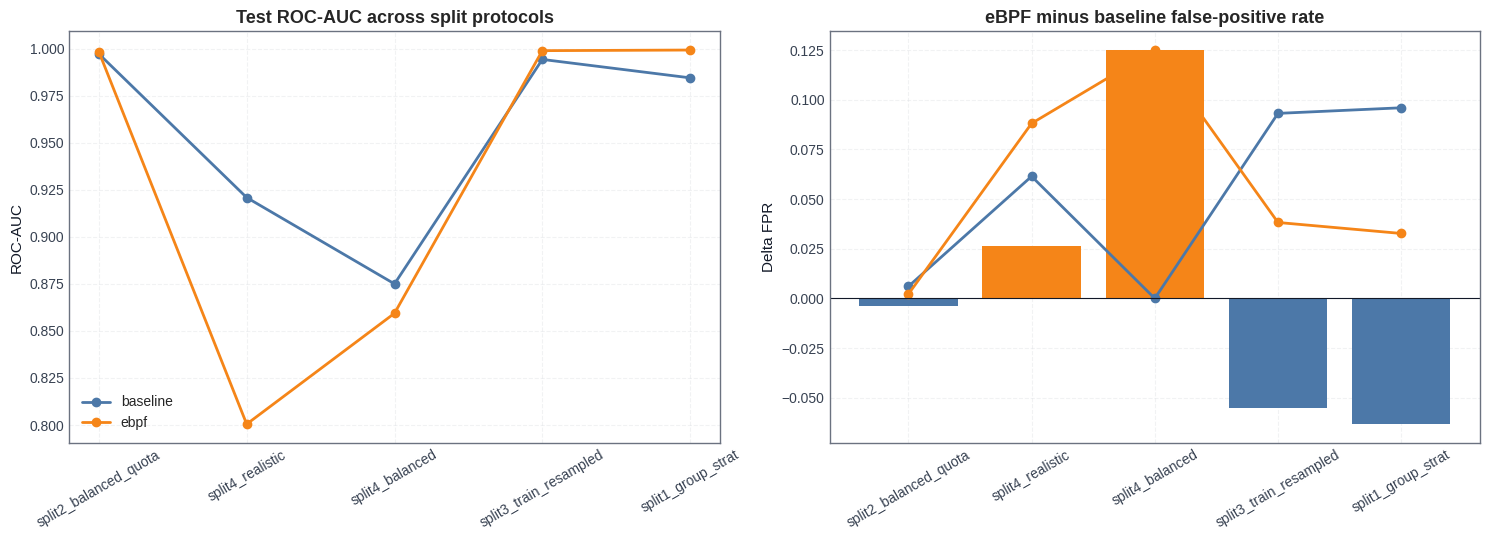

[+] Saved supporting split response plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/supporting_split_response_seed104.png


In [20]:
if not supporting_df.empty:
    plot_df = supporting_df.copy()
    role_rank = {
        'model_selection': 0,
        'headline_generalization': 1,
        'balanced_fairness': 2,
        'resampled_training': 3,
        'leakage_diagnostic': 4,
    }
    split_order = (
        plot_df[['split', 'role']]
        .drop_duplicates()
        .assign(_rank=lambda d: d['role'].map(role_rank))
        .sort_values(['_rank', 'split'])['split']
        .tolist()
    )
    plot_df['split'] = pd.Categorical(plot_df['split'], split_order, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for fs_name, color in [('baseline', BASELINE_COLOR), ('ebpf', EBPF_COLOR)]:
        subset = plot_df[plot_df['feature_set'] == fs_name].sort_values('split')
        axes[0].plot(subset['split'].astype(str), subset['test_roc_auc'], marker='o', linewidth=2, color=color, label=fs_name)
        axes[1].plot(subset['split'].astype(str), subset['test_fpr'], marker='o', linewidth=2, color=color, label=fs_name)
    axes[0].set_title('Test ROC-AUC across split protocols')
    axes[0].set_ylabel('ROC-AUC')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend()

    delta_df = (
        plot_df.pivot(index='split', columns='feature_set', values='test_fpr')
        .assign(delta_fpr=lambda d: d['ebpf'] - d['baseline'])
        .reset_index()
    )
    bar_colors = [EBPF_COLOR if v > 0 else BASELINE_COLOR for v in delta_df['delta_fpr']]
    axes[1].bar(delta_df['split'], delta_df['delta_fpr'], color=bar_colors)
    axes[1].axhline(0, color='#111827', linewidth=0.8)
    axes[1].set_title('eBPF minus baseline false-positive rate')
    axes[1].set_ylabel('Delta FPR')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    out = REPORTS_DIR / f'supporting_split_response_seed{RANDOM_SEED}.png'
    savefig(fig, out)
    plt.show()
    print(f'[+] Saved supporting split response plot: {out}')


## Main Comparison with Uncertainty

ROC-AUC and PR-AUC with bootstrap 95% CIs, plus the matched-recall operating point. This is the primary evidence for RQ1 and RQ5.

feature_set        model  roc_auc  roc_low  roc_high  pr_auc  precision  recall    fpr
   baseline hgb_balanced   0.9209   0.9201    0.9216  0.8638     0.8328  0.3680 0.0614
       ebpf hgb_balanced   0.8005   0.7994    0.8016  0.7512     0.7762  0.3675 0.0881


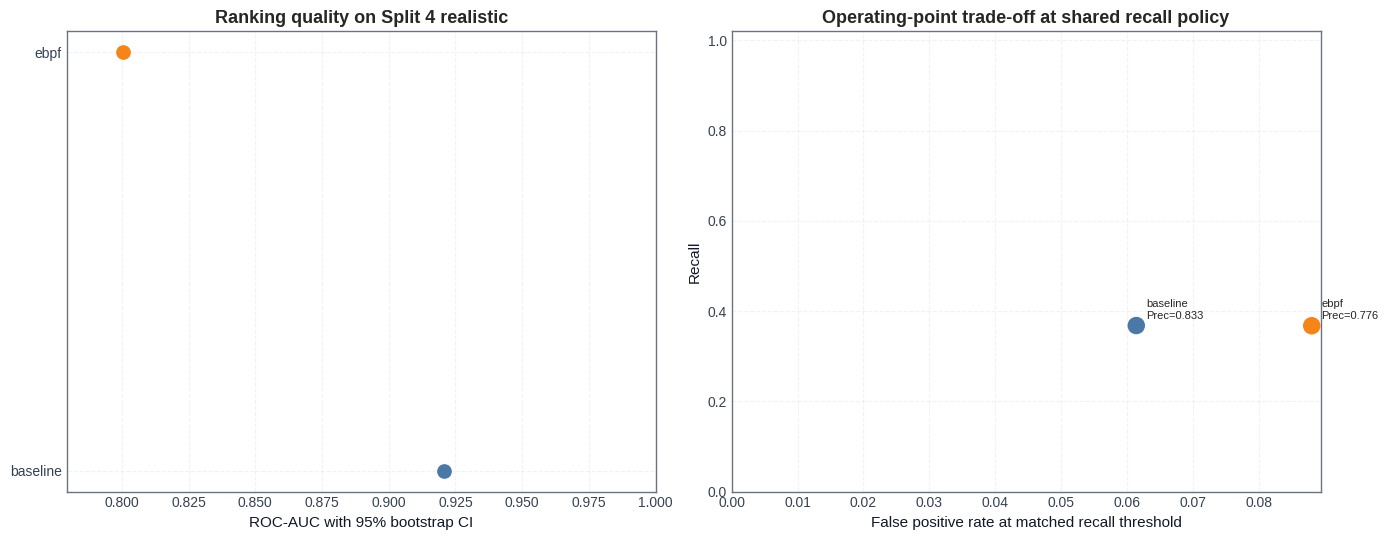

[+] Saved headline uncertainty plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/headline_metric_forest_seed104.png


In [21]:
if headline_results:
    summary_rows = []
    for fs_name in ['baseline', 'ebpf']:
        if fs_name not in headline_results:
            continue
        r = headline_results[fs_name]
        roc_samples = bootstrap_auc(np.array(r['y_test']), np.array(r['y_prob']), n=300, seed=RANDOM_SEED)
        roc_low, roc_high = bootstrap_ci(roc_samples)
        summary_rows.append({
            'feature_set': fs_name,
            'model': r['model_name'],
            'roc_auc': r['test']['roc_auc'],
            'roc_low': roc_low,
            'roc_high': roc_high,
            'pr_auc': r['test']['pr_auc'],
            'precision': r['test']['precision'],
            'recall': r['test']['recall'],
            'fpr': r['test']['fpr'],
        })
    headline_summary_df = pd.DataFrame(summary_rows)
    print(headline_summary_df.to_string(index=False, float_format='{:.4f}'.format))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    ypos = np.arange(len(headline_summary_df))
    colors = [BASELINE_COLOR if fs == 'baseline' else EBPF_COLOR for fs in headline_summary_df['feature_set']]

    axes[0].errorbar(
        headline_summary_df['roc_auc'], ypos,
        xerr=[headline_summary_df['roc_auc'] - headline_summary_df['roc_low'], headline_summary_df['roc_high'] - headline_summary_df['roc_auc']],
        fmt='o', color='#1F2937', ecolor='#6B7280', elinewidth=2, capsize=4,
    )
    for y, (_, row) in zip(ypos, headline_summary_df.iterrows()):
        axes[0].scatter(row['roc_auc'], y, s=130, color=colors[y], edgecolor='white', linewidth=0.8, zorder=3)
    axes[0].set_yticks(ypos)
    axes[0].set_yticklabels(headline_summary_df['feature_set'])
    axes[0].set_xlim(max(0.0, headline_summary_df['roc_low'].min() - 0.02), 1.0)
    axes[0].set_xlabel('ROC-AUC with 95% bootstrap CI')
    axes[0].set_title('Ranking quality on Split 4 realistic')

    axes[1].scatter(headline_summary_df['fpr'], headline_summary_df['recall'], s=180, color=colors, edgecolor='white', linewidth=0.8)
    for _, row in headline_summary_df.iterrows():
        axes[1].annotate(
            f"{row['feature_set']}\nPrec={row['precision']:.3f}",
            (row['fpr'], row['recall']), xytext=(7, 5), textcoords='offset points', fontsize=8,
        )
    axes[1].set_xlabel('False positive rate at matched recall threshold')
    axes[1].set_ylabel('Recall')
    axes[1].set_xlim(left=0)
    axes[1].set_ylim(0, 1.02)
    axes[1].set_title('Operating-point trade-off at shared recall policy')

    plt.tight_layout()
    out = REPORTS_DIR / f'headline_metric_forest_seed{RANDOM_SEED}.png'
    savefig(fig, out)
    plt.show()
    print(f'[+] Saved headline uncertainty plot: {out}')


## Formal Paired Inference

Paired cluster bootstrap (1,000 resamples) using the 5-tuple flow session as the clustering unit. Estimates 95% CI for eBPF minus baseline on AUC, PR-AUC, F1, and recall.

In [22]:
from scipy.stats import binomtest

def choose_cluster_keys(df: pd.DataFrame) -> pd.Series:
    """Choose a defensible resampling unit for the paired cluster bootstrap."""
    preferred = ['run_id', 'k', 'day', 'orig_h', 'src_ip']
    for col in preferred:
        if col in df.columns:
            vals = df[col].astype(str).fillna('nan')
            if vals.nunique(dropna=False) > 1:
                return vals.rename('cluster_key')
    return pd.Series(np.arange(len(df)), index=df.index, name='cluster_key').astype(str)

def exact_mcnemar_from_predictions(y_true: np.ndarray, pred_a: np.ndarray, pred_b: np.ndarray) -> dict:
    y_true = np.asarray(y_true).astype(int)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    correct_a = (pred_a == y_true).astype(int)
    correct_b = (pred_b == y_true).astype(int)
    b = int(np.sum((correct_a == 1) & (correct_b == 0)))
    c = int(np.sum((correct_a == 0) & (correct_b == 1)))
    discordant = b + c
    if discordant == 0:
        p_value = 1.0
    else:
        p_value = float(binomtest(min(b, c), n=discordant, p=0.5, alternative='two-sided').pvalue)
    return {
        'baseline_correct_ebpf_wrong': b,
        'baseline_wrong_ebpf_correct': c,
        'discordant_total': discordant,
        'ebpf_minus_baseline_discordant_delta': c - b,
        'p_value_exact_mcnemar': p_value,
    }

def metric_from_scores(y_true: np.ndarray, y_score: np.ndarray, threshold: float, metric: str) -> float:
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    pred = (y_score >= float(threshold)).astype(int)
    out = binary_metrics(y_true, pred, y_score)
    val = out.get(metric)
    return float(val) if val is not None else np.nan

def _fmt_eta(seconds: float) -> str:
    seconds = max(0, int(round(float(seconds))))
    h, rem = divmod(seconds, 3600)
    m, s = divmod(rem, 60)
    if h:
        return f'{h:d}h {m:02d}m {s:02d}s'
    if m:
        return f'{m:d}m {s:02d}s'
    return f'{s:d}s'

def paired_cluster_bootstrap_metric_deltas(
    df_pairs: pd.DataFrame,
    cluster_keys: pd.Series,
    *,
    metrics: list[str],
    n_boot: int = 1000,
    seed: int = RANDOM_SEED,
    progress_every: int = 50,
) -> pd.DataFrame:
    work = df_pairs.copy().reset_index(drop=True)
    clusters = pd.Series(cluster_keys).reset_index(drop=True).astype(str)
    cluster_name = str(getattr(cluster_keys, 'name', None) or 'cluster_key')
    work['__cluster__'] = clusters

    cluster_to_rows = {
        cluster: np.asarray(idx, dtype=int)
        for cluster, idx in work.groupby('__cluster__').groups.items()
    }
    cluster_names = np.array(list(cluster_to_rows.keys()), dtype=object)

    total_metrics = len(metrics)
    total_iterations = int(total_metrics * n_boot)
    completed_iterations = 0
    overall_start = time.perf_counter()

    print('[*] Starting paired cluster bootstrap')
    print(f'    rows             : {len(work):,}')
    print(f'    clusters         : {len(cluster_names):,} ({cluster_name})')
    print(f'    metrics          : {total_metrics}')
    print(f'    bootstraps/metric: {int(n_boot):,}')
    print(f'    total iterations : {total_iterations:,}')

    rows = []
    rng = np.random.default_rng(seed)
    for metric_idx, metric in enumerate(metrics, start=1):
        metric_start = time.perf_counter()
        print(f'\n[*] Bootstrap metric {metric_idx}/{total_metrics}: {metric}')
        boot_deltas = []
        for boot_idx in range(1, int(n_boot) + 1):
            sampled_clusters = rng.choice(cluster_names, size=len(cluster_names), replace=True)
            take_idx = np.concatenate([cluster_to_rows[c] for c in sampled_clusters])
            bs = work.iloc[take_idx]
            try:
                base_val = metric_from_scores(bs['y_true'].to_numpy(), bs['baseline_score'].to_numpy(), bs['baseline_threshold'].iloc[0], metric)
                ebpf_val = metric_from_scores(bs['y_true'].to_numpy(), bs['ebpf_score'].to_numpy(), bs['ebpf_threshold'].iloc[0], metric)
                if np.isfinite(base_val) and np.isfinite(ebpf_val):
                    boot_deltas.append(ebpf_val - base_val)
            except Exception:
                pass

            completed_iterations += 1
            if boot_idx == 1 or boot_idx == int(n_boot) or boot_idx % max(1, int(progress_every)) == 0:
                metric_elapsed = time.perf_counter() - metric_start
                metric_rate = boot_idx / max(metric_elapsed, 1e-9)
                metric_eta = (int(n_boot) - boot_idx) / max(metric_rate, 1e-9)
                overall_elapsed = time.perf_counter() - overall_start
                overall_rate = completed_iterations / max(overall_elapsed, 1e-9)
                overall_eta = (total_iterations - completed_iterations) / max(overall_rate, 1e-9)
                print(
                    f'    {metric}: {boot_idx:>4d}/{int(n_boot):,} bootstraps | '
                    f'metric elapsed={_fmt_eta(metric_elapsed)} eta={_fmt_eta(metric_eta)} | '
                    f'overall {completed_iterations:,}/{total_iterations:,} eta={_fmt_eta(overall_eta)} | '
                    f'success={len(boot_deltas):,}'
                )

        point_base = metric_from_scores(work['y_true'].to_numpy(), work['baseline_score'].to_numpy(), work['baseline_threshold'].iloc[0], metric)
        point_ebpf = metric_from_scores(work['y_true'].to_numpy(), work['ebpf_score'].to_numpy(), work['ebpf_threshold'].iloc[0], metric)
        point_delta = point_ebpf - point_base
        arr = np.asarray(boot_deltas, dtype=float)
        rows.append({
            'split_name': 'split4_realistic',
            'comparison': 'ebpf_minus_baseline',
            'metric': metric,
            'baseline_value': float(point_base),
            'ebpf_value': float(point_ebpf),
            'delta': float(point_delta),
            'bootstrap_mean_delta': float(np.mean(arr)) if arr.size else np.nan,
            'ci_low': float(np.quantile(arr, 0.025)) if arr.size else np.nan,
            'ci_high': float(np.quantile(arr, 0.975)) if arr.size else np.nan,
            'n_boot_success': int(arr.size),
            'n_clusters': int(len(cluster_names)),
            'cluster_column_used': cluster_name,
        })
        print(f'    completed {metric} in {_fmt_eta(time.perf_counter() - metric_start)}')

    print(f'\n[+] Paired cluster bootstrap finished in {_fmt_eta(time.perf_counter() - overall_start)}')
    return pd.DataFrame(rows)

# Load only the cluster-key + label columns. Avoids reading 30+ cols unnecessarily
_CLUSTER_COLS = ['run_id', 'k', 'day', 'orig_h', 'src_ip', 'label_family']
import pyarrow.parquet as _pq
_schema_cols = set(_pq.read_schema(str(SPLITS_4_BASELINE / 'test_realistic.parquet')).names)
_load_cols = [c for c in _CLUSTER_COLS if c in _schema_cols]
baseline_split4_df = pd.read_parquet(SPLITS_4_BASELINE / 'test_realistic.parquet', columns=_load_cols)
ebpf_split4_df     = pd.read_parquet(SPLITS_4_EBPF     / 'test_realistic.parquet', columns=_load_cols)
if len(baseline_split4_df) != len(ebpf_split4_df):
    raise ValueError('Split 4 realistic baseline/eBPF test sets are not row-aligned, so paired inference cannot be run safely.')

pairs_df = pd.DataFrame({
    'y_true': np.asarray(headline_results['baseline']['y_test']).astype(int),
    'baseline_score': np.asarray(headline_results['baseline']['y_prob'], dtype=float),
    'ebpf_score': np.asarray(headline_results['ebpf']['y_prob'], dtype=float),
    'baseline_pred': np.asarray(headline_results['baseline']['y_pred']).astype(int),
    'ebpf_pred': np.asarray(headline_results['ebpf']['y_pred']).astype(int),
    'baseline_threshold': float(headline_results['baseline']['threshold']),
    'ebpf_threshold': float(headline_results['ebpf']['threshold']),
})

if 'label_family' in baseline_split4_df.columns and 'label_family' in ebpf_split4_df.columns:
    same_labels = baseline_split4_df['label_family'].astype(str).reset_index(drop=True).equals(
        ebpf_split4_df['label_family'].astype(str).reset_index(drop=True)
    )
    if not same_labels:
        raise ValueError('Split 4 realistic baseline/eBPF label_family columns are not aligned.')

cluster_series = choose_cluster_keys(baseline_split4_df).reset_index(drop=True)
metrics_for_inference = ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall', 'fpr']
paired_boot_df = paired_cluster_bootstrap_metric_deltas(
    pairs_df,
    cluster_series,
    metrics=metrics_for_inference,
    n_boot=1000,
    seed=RANDOM_SEED,
    progress_every=50,
)
paired_boot_csv = REPORTS_DIR / f'headline_split4_realistic_paired_cluster_bootstrap_seed{RANDOM_SEED}.csv'
paired_boot_df.to_csv(paired_boot_csv, index=False)

mcnemar_res = exact_mcnemar_from_predictions(
    pairs_df['y_true'].to_numpy(),
    pairs_df['baseline_pred'].to_numpy(),
    pairs_df['ebpf_pred'].to_numpy(),
)
mcnemar_df = pd.DataFrame([{
    'split_name': 'split4_realistic',
    'comparison': 'ebpf_vs_baseline',
    **mcnemar_res,
}])
mcnemar_csv = REPORTS_DIR / f'headline_split4_realistic_exact_mcnemar_seed{RANDOM_SEED}.csv'
mcnemar_df.to_csv(mcnemar_csv, index=False)

formal_meta = {
    'split_name': 'split4_realistic',
    'comparison': 'ebpf_minus_baseline',
    'bootstrap_type': 'paired_cluster_bootstrap',
    'cluster_column_used': str(cluster_series.name if cluster_series.name is not None else 'cluster_key'),
    'n_rows': int(len(pairs_df)),
    'n_clusters': int(pd.Series(cluster_series).nunique()),
    'metrics': metrics_for_inference,
    'threshold_mode': 'matched_recall',
    'baseline_threshold': float(headline_results['baseline']['threshold']),
    'ebpf_threshold': float(headline_results['ebpf']['threshold']),
    'random_seed': int(RANDOM_SEED),
}
formal_meta_path = REPORTS_DIR / f'headline_split4_realistic_formal_inference_meta_seed{RANDOM_SEED}.json'
formal_meta_path.write_text(json.dumps(formal_meta, indent=2))

print('[*] Formal paired inference: Split 4 realistic')
print(f'    cluster column used: {formal_meta["cluster_column_used"]}')
print(paired_boot_df.to_string(index=False, float_format='{:.4f}'.format))
print()
print(mcnemar_df.to_string(index=False, float_format='{:.6f}'.format))
print(f'\n[+] Saved paired bootstrap table: {paired_boot_csv}')
print(f'[+] Saved exact McNemar table  : {mcnemar_csv}')
print(f'[+] Saved inference metadata   : {formal_meta_path}')

# Free large DataFrames after cluster keys are extracted
del baseline_split4_df, ebpf_split4_df
gc.collect()

[*] Starting paired cluster bootstrap
    rows             : 546,207
    clusters         : 397,286 (cluster_key)
    metrics          : 6
    bootstraps/metric: 1,000
    total iterations : 6,000

[*] Bootstrap metric 1/6: roc_auc
    roc_auc:    1/1,000 bootstraps | metric elapsed=2s eta=27m 35s | overall 1/6,000 eta=2h 45m 43s | success=1
    roc_auc:   50/1,000 bootstraps | metric elapsed=1m 16s eta=24m 02s | overall 50/6,000 eta=2h 30m 34s | success=50
    roc_auc:  100/1,000 bootstraps | metric elapsed=2m 32s eta=22m 45s | overall 100/6,000 eta=2h 29m 06s | success=100
    roc_auc:  150/1,000 bootstraps | metric elapsed=3m 47s eta=21m 27s | overall 150/6,000 eta=2h 27m 40s | success=150
    roc_auc:  200/1,000 bootstraps | metric elapsed=5m 02s eta=20m 09s | overall 200/6,000 eta=2h 26m 06s | success=200
    roc_auc:  250/1,000 bootstraps | metric elapsed=6m 17s eta=18m 51s | overall 250/6,000 eta=2h 24m 31s | success=250
    roc_auc:  300/1,000 bootstraps | metric elapsed=7m 32s

33

## ROC and PR Curves

ROC and precision-recall curves for both models on the Split 4 realistic test, with the matched-recall operating point marked.

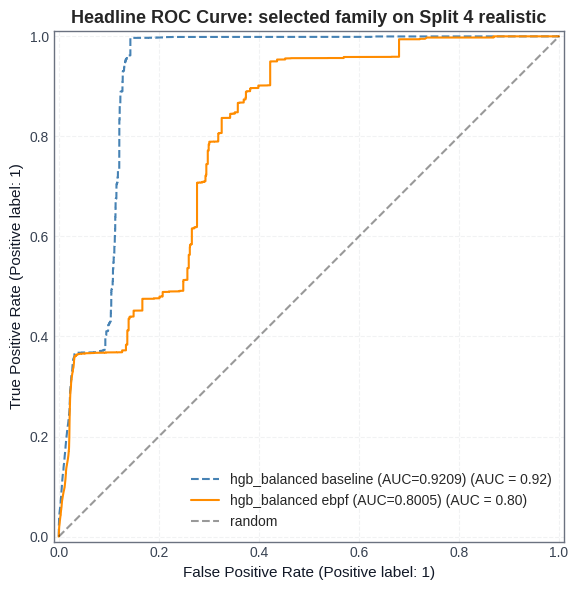

[+] Saved ROC plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/roc_hgb_split4_realistic_seed104.png


In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for fs_name, colour, ls in [('baseline', 'steelblue', '--'), ('ebpf', 'darkorange', '-')]:
    if fs_name not in headline_results:
        continue
    r = headline_results[fs_name]
    yt = np.array(r['y_test'])
    yp = np.array(r['y_prob'])
    auc = r['test']['roc_auc']
    RocCurveDisplay.from_predictions(
        yt, yp, ax=ax,
        name=f'{r["model_name"]} {fs_name} (AUC={auc:.4f})',
        color=colour, linestyle=ls,
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='random')
ax.set_title('Headline ROC Curve: selected family on Split 4 realistic')
ax.legend()
plt.tight_layout()
out_png = REPORTS_DIR / f'roc_hgb_split4_realistic_seed{RANDOM_SEED}.png'
plt.savefig(out_png, dpi=150)
plt.show()
print(f'[+] Saved ROC plot: {out_png}')


## Split 5 Robustness Metadata Summary

Fold-level metadata summary from Split 5. Used as a robustness diagnostic and not a headline result.

In [24]:
robustness_rows = []
for fs_name, split5_dir in [('baseline', SPLITS_5_BASELINE), ('ebpf', SPLITS_5_EBPF)]:
    meta_path = Path(split5_dir) / 'folds_meta.json'
    if not meta_path.exists():
        print(f'[!] Split 5 metadata not found for {fs_name}: {meta_path}')
        continue
    meta = json.loads(meta_path.read_text())
    folds = meta.get('folds', [])
    if not folds:
        print(f'[!] Split 5 metadata is empty for {fs_name}: {meta_path}')
        continue
    train_rows = [f['train_rows'] for f in folds]
    test_rows = [f['test_rows'] for f in folds]
    test_attacks = [f['test_attacks'] for f in folds]
    unseen_count = sum(1 for f in folds if f.get('unseen_in_train'))
    robustness_rows.append({
        'feature_set': fs_name,
        'n_folds': len(folds),
        'mean_train_rows': float(np.mean(train_rows)),
        'mean_test_rows': float(np.mean(test_rows)),
        'mean_test_attacks': float(np.mean(test_attacks)),
        'folds_with_unseen_families': int(unseen_count),
    })

robustness_df = pd.DataFrame(robustness_rows)
if not robustness_df.empty:
    print(robustness_df.to_string(index=False, float_format='{:.2f}'.format))
    robustness_csv = REPORTS_DIR / f'robustness_split5_metadata_seed{RANDOM_SEED}.csv'
    robustness_df.to_csv(robustness_csv, index=False)
    print(f'\n[+] Saved Split 5 metadata summary: {robustness_csv}')
else:
    print('[!] No Split 5 metadata available to summarize.')


feature_set  n_folds  mean_train_rows  mean_test_rows  mean_test_attacks  folds_with_unseen_families
   baseline       15       1692188.80       423047.20           89471.60                          10
       ebpf       15       1692188.80       423047.20           89471.60                          10

[+] Saved Split 5 metadata summary: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/robustness_split5_metadata_seed104.csv


## Summary

**RQ1:** eBPF features reduce detection accuracy on the out-of-distribution Friday holdout.
- Baseline ROC-AUC 0.921 vs eBPF 0.801 (delta = -0.120); PR-AUC 0.864 vs 0.751
- Train-test gap: baseline 0.079, eBPF 0.200 (roughly 2.5x larger)
- Direction is consistent across all 5 seeds. Seed 104 is an outlier with an unusually large eBPF gap (0.205)

**RQ5:** eBPF increases false positives at matched recall.
- FPR: baseline 6.14% vs eBPF 8.81% (+2.67 pp, roughly 7,950 extra false alarms on the realistic test set)

The eBPF numeric aggregates hurt generalisation in this PCAP replay setup. The negative result holds across all seeds.